In [73]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SB03.txt")    

In [74]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = 50  # Anzahl Anfragen pro Episode; entspricht Instanz "WC4" (K=12, |N|=1000, C=10, T_d=10) aus Tabelle 1 des Papers, Z*=1.53
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
pool_size = DRAUSP_data.pool_size
print(f"Number of slots (K): {K}")
print(f"Number of requests per episode (T_d): {T_d}")
print(f"Pool size (|N|): {pool_size}")
print(f"Capacity vector (C_k): {C_k}")
print(f"Instance: {instance}")

Number of slots (K): 8
Number of requests per episode (T_d): 50
Pool size (|N|): 50
Capacity vector (C_k): [10, 10, 10, 10, 10, 10, 10, 10]
Instance: [[0.414, 1, 1, 2, 1, 0, 0, 0, 0], [0.39, 2, 1, 2, 1, 0, 0, 0, 0], [0.205, 3, 1, 1, 2, 0, 0, 0, 0], [0.614, 1, 2, 1, 1, 0, 0, 0, 0], [0.184, 1, 1, 1, 3, 0, 0, 0, 0], [0.236, 1, 1, 1, 1, 0, 0, 0, 0], [0.255, 3, 3, 1, 1, 0, 0, 0, 0], [0.137, 2, 1, 2, 2, 0, 0, 0, 0], [0.779, 1, 1, 1, 1, 0, 0, 0, 0], [0.089, 2, 1, 1, 1, 0, 0, 0, 0], [0.258, 2, 2, 1, 1, 0, 0, 0, 0], [0.747, 1, 1, 1, 1, 0, 0, 0, 0], [0.393, 1, 1, 1, 2, 0, 0, 0, 0], [0.544, 1, 1, 2, 1, 0, 0, 0, 0], [0.701, 1, 1, 1, 1, 0, 0, 0, 0], [0.718, 1, 1, 1, 1, 0, 0, 0, 0], [0.552, 1, 2, 1, 3, 0, 0, 0, 0], [0.092, 3, 2, 2, 1, 0, 0, 0, 0], [0.961, 1, 1, 1, 1, 0, 0, 0, 0], [0.639, 3, 1, 2, 1, 0, 0, 0, 0], [0.502, 1, 1, 1, 1, 0, 0, 0, 0], [0.205, 2, 1, 2, 2, 0, 0, 0, 0], [0.432, 1, 1, 1, 1, 0, 0, 0, 0], [0.74, 1, 2, 1, 4, 0, 0, 0, 0], [0.628, 1, 1, 2, 1, 0, 0, 0, 0], [0.603, 1, 1, 1, 1, 0, 0, 

In [75]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)
env.reset(show_instance = True)

Geladene Instanz:
  Anfrage 1: [0.808, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 2: [0.184, 1, 1, 1, 3, 0, 0, 0, 0]
  Anfrage 3: [0.74, 1, 2, 1, 4, 0, 0, 0, 0]
  Anfrage 4: [0.258, 2, 2, 1, 1, 0, 0, 0, 0]
  Anfrage 5: [0.432, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 6: [0.808, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 7: [0.205, 2, 1, 2, 2, 0, 0, 0, 0]
  Anfrage 8: [0.639, 3, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 9: [0.883, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 10: [0.581, 3, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 11: [0.794, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 12: [0.808, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 13: [0.747, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 14: [0.718, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 15: [0.961, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 16: [0.794, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 17: [0.581, 3, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 18: [0.581, 3, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 19: [0.222, 1, 2, 3, 1, 0, 0, 0, 0]
  Anfrage 20: [0.383, 3, 5, 1, 1, 0, 0, 0, 0]
  Anfrage 21: [0.218, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 22: [0.699, 3, 1

(array([ 1.   , 10.   , 10.   , 10.   , 10.   , 10.   , 10.   , 10.   ,
        10.   ,  0.808,  1.   ,  1.   ,  1.   ,  1.   ,  0.   ,  0.   ,
         0.   ,  0.   ], dtype=float32),
 {'valid_actions': [0, 1, 2, 3, 4, 5]})

## Hier kann getestet werden ob alle Transitions korrekt funktionieren
Mit render bekommt man eine Übersicht was gerade los ist

In [76]:
obs, info = env.reset()
print(obs)
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
print(terminated)
env.render()

[ 1.    10.    10.    10.    10.    10.    10.    10.    10.     0.639
  3.     1.     2.     1.     0.     0.     0.     0.   ]
t=2    Caps=[7, 9, 8, 9, 10, 10, 10, 10]  r=0.92  q=[1, 1, 2, 1, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]
t=3    Caps=[6, 8, 6, 8, 10, 10, 10, 10]  r=0.96  q=[1, 1, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]
t=4    Caps=[5, 7, 5, 7, 10, 10, 10, 10]  r=0.54  q=[1, 2, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]
t=5    Caps=[4, 5, 4, 6, 10, 10, 10, 10]  r=0.38  q=[3, 5, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 1, 3, 4, 5]
t=6    Caps=[1, 0, 3, 5, 10, 10, 10, 10]  r=0.54  q=[1, 2, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 3, 4, 5]
True
t=7    Caps=[0, -2, 2, 4, 10, 10, 10, 10]  r=0.54  q=[1, 1, 2, 1, 0, 0, 0, 0]  Valid Actions: [0, 3, 4, 5]


In [77]:
from training.dqn_agent import DQNAgent
from models.standard_dqn import DQNNetwork
agent = DQNAgent(env, QnetworkClass=DQNNetwork, monotonicity_penalty=False, reject_bias = 0.75, gamma = 0.99, epsilon_decay_steps=50000)

In [78]:
reward_history, monotonicity_violations, depth_history = agent.train(num_episodes=20000)

  Systematic monotonicity (Episode 1): C_k: 75.8%, t: 45.7%, r: 29.8%, q: 69.7%, mixed: 78.9%


Episode   50/20000  Reward:     5.94  Avg(50):     4.92  Tiefe:   43  Avg-Tiefe(50):   37.6  ε: 0.965
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 0.0%, r: 100.0%, q: 83.7%, mixed: 98.9%
Episode  100/20000  Reward:     4.09  Avg(50):     5.28  Tiefe:   28  Avg-Tiefe(50):   37.6  ε: 0.931
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 4.3%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  150/20000  Reward:     3.41  Avg(50):     4.96  Tiefe:   25  Avg-Tiefe(50):   34.8  ε: 0.901
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 1.4%, r: 100.0%, q: 89.5%, mixed: 100.0%
Episode  200/20000  Reward:     7.03  Avg(50):     5.75  Tiefe:   40  Avg-Tiefe(50):   36.6  ε: 0.871
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 15.3%, r: 100.0%, q: 82.7%, mixed: 100.0%
Episode  250/20000  Reward:     5.51  Avg(50):     5.74  Tiefe:   30  Avg-Tiefe(50):   39.1  ε: 0.839
  Systematic monotonicity (Episode 251): C_k: 100.0%, t: 13.3%, r: 99.1%, q: 84.6%, mixed: 99.6%
E

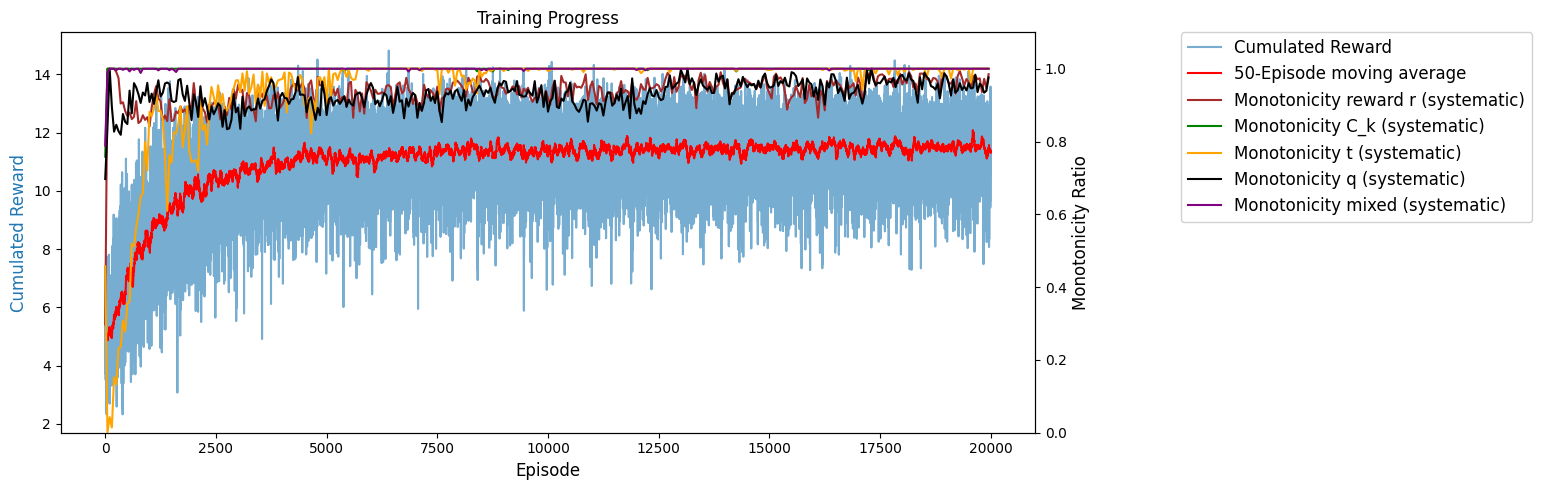

In [79]:
from training.plotting import plot_training_progress, plot_depth_epsilon

plot_training_progress(reward_history, monotonicity_violations)

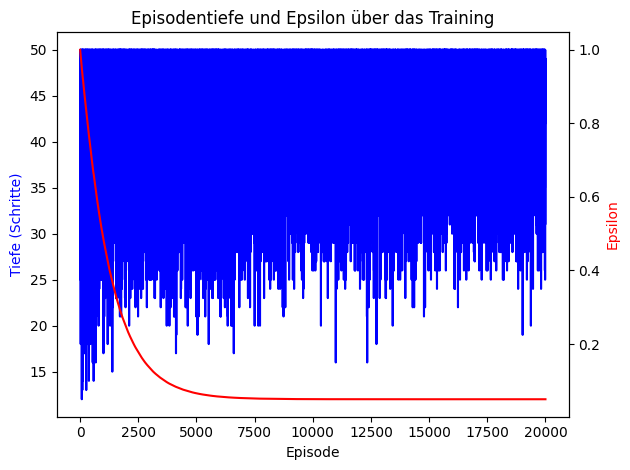

In [80]:
plot_depth_epsilon(depth_history)

## Beispiel-Durchlauf des trainierten Agenten

In [81]:
agent.epsilon = 0.0  # rein exploitativ, keine Exploration

obs, info = env.reset(show_instance = True)
done = False
total_reward = 0.0

while not done:
    action = agent.select_action(obs)
    print(f"Aktion gewählt: {action}")
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    total_reward += reward
    done = terminated or truncated

print(f"\nGesamtreward (greedy Durchlauf): {total_reward:.2f}")

Geladene Instanz:
  Anfrage 1: [0.393, 1, 1, 1, 2, 0, 0, 0, 0]
  Anfrage 2: [0.808, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 3: [0.236, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 4: [0.184, 1, 1, 1, 3, 0, 0, 0, 0]
  Anfrage 5: [0.843, 1, 3, 1, 1, 0, 0, 0, 0]
  Anfrage 6: [0.734, 2, 2, 1, 2, 0, 0, 0, 0]
  Anfrage 7: [0.502, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 8: [0.961, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 9: [0.603, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 10: [0.398, 1, 2, 4, 1, 0, 0, 0, 0]
  Anfrage 11: [0.542, 1, 2, 1, 1, 0, 0, 0, 0]
  Anfrage 12: [0.747, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 13: [0.614, 1, 2, 1, 1, 0, 0, 0, 0]
  Anfrage 14: [0.137, 2, 1, 2, 2, 0, 0, 0, 0]
  Anfrage 15: [0.092, 3, 2, 2, 1, 0, 0, 0, 0]
  Anfrage 16: [0.603, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 17: [0.432, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 18: [0.09, 1, 1, 1, 3, 0, 0, 0, 0]
  Anfrage 19: [0.614, 1, 2, 1, 1, 0, 0, 0, 0]
  Anfrage 20: [0.542, 1, 2, 1, 1, 0, 0, 0, 0]
  Anfrage 21: [0.393, 1, 1, 1, 2, 0, 0, 0, 0]
  Anfrage 22: [0.542, 1, 2

## Analyse der Reward-History

Diese Zelle berechnet einfache Kennzahlen (Mean, Std, Median, AUC, Final-Mean) aus der vorhandenen `reward_history`-Liste und zeigt einen Plot mit gleitendem Durchschnitt.

Episoden: 20000
Mean: 10.9680, Std: 1.5842, Median: 11.2650
Max: 14.8190, Min: 2.3210


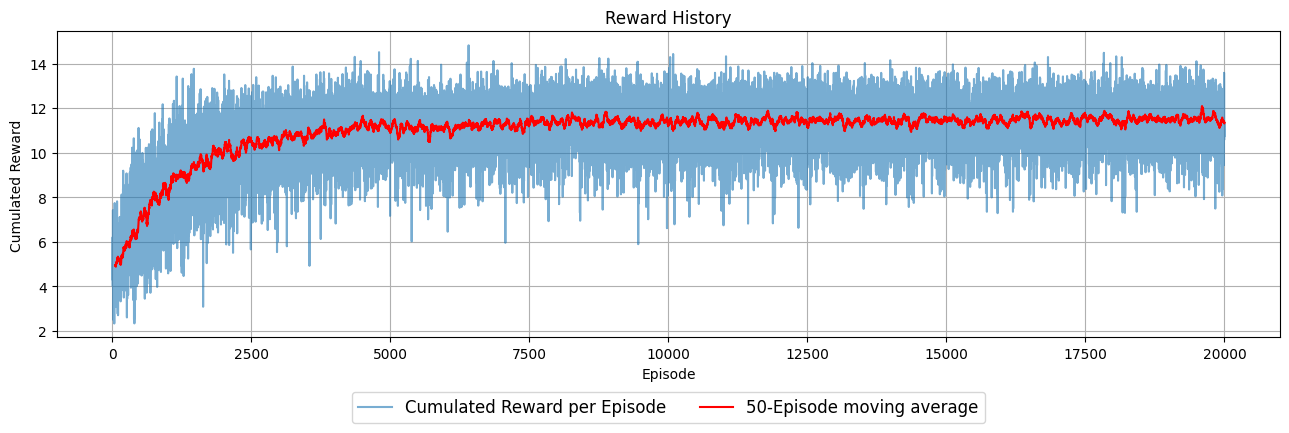

{'n': 20000,
 'mean': 10.967954793153703,
 'std': 1.5842470150340622,
 'median': 11.264999970793724,
 'max': 14.81900018453598,
 'min': 2.320999965071678}

In [82]:
from training.plotting import plot_reward_moving_average
plot_reward_moving_average(reward_history, window=50)

## Evaluationsphase (eingefrorene Parameter, epsilon=0)

Nach abgeschlossenem Training werden die Netzgewichte fixiert (keine weiteren Trainingsschritte, `epsilon=0`, reines Exploitation) und für 10.000 Episoden evaluiert, um eine stabile Schätzung der Performance zu erhalten.

In [83]:
eval_rewards, eval_depths = agent.evaluate(num_episodes=10000)

[Eval] Episode   500/10000  Reward:    11.05  Avg(500):    11.70  Avg-Tiefe(500):   42.7
[Eval] Episode  1000/10000  Reward:    10.64  Avg(500):    11.69  Avg-Tiefe(500):   42.8
[Eval] Episode  1500/10000  Reward:    10.96  Avg(500):    11.73  Avg-Tiefe(500):   43.1
[Eval] Episode  2000/10000  Reward:    10.63  Avg(500):    11.71  Avg-Tiefe(500):   42.5
[Eval] Episode  2500/10000  Reward:    11.97  Avg(500):    11.70  Avg-Tiefe(500):   42.8
[Eval] Episode  3000/10000  Reward:    10.93  Avg(500):    11.72  Avg-Tiefe(500):   42.7
[Eval] Episode  3500/10000  Reward:    12.07  Avg(500):    11.65  Avg-Tiefe(500):   43.1
[Eval] Episode  4000/10000  Reward:    12.35  Avg(500):    11.70  Avg-Tiefe(500):   42.7
[Eval] Episode  4500/10000  Reward:    11.73  Avg(500):    11.65  Avg-Tiefe(500):   43.1
[Eval] Episode  5000/10000  Reward:    11.31  Avg(500):    11.67  Avg-Tiefe(500):   42.8
[Eval] Episode  5500/10000  Reward:    11.19  Avg(500):    11.76  Avg-Tiefe(500):   42.3
[Eval] Episode  6000/

Eval-Episoden: 10000
Mean: 11.6954, Std: 0.8379, Median: 11.7450
Max: 14.7480, Min: 7.0140


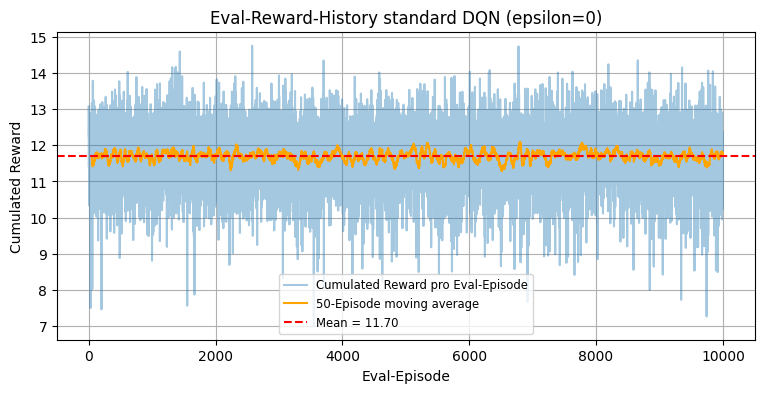

In [84]:
from training.plotting import plot_eval_rewards

eval_stats = plot_eval_rewards(eval_rewards, title="Eval-Reward-History standard DQN (epsilon=0)")